# Proyecto de Clasificación Multiclase: Estimación de Niveles de Obesidad

Este proyecto surge en el marco de la salud preventiva, utilizando el Machine Learning para clasificar niveles de obesidad basados en hábitos alimenticios y condición física.

El objetivo principal es desarrollar un modelo capaz de predecir con precisión una de las 7 categorías de peso (desde Peso Insuficiente hasta Obesidad Tipo III). Este es un problema de clasificación multiclase donde buscaremos no solo la precisión global, sino un equilibrio en las métricas por clase y un overfitting controlado inferior al 5%.

## Variables Demográficas y Físicas:

Gender (Género): Género del encuestado (Masculino / Femenino).

Age (Edad): Edad del encuestado en años.

Height (Altura): Altura en metros.

Weight (Peso): Peso en kilogramos.

## Hábitos Alimenticios:

family_history_with_overweight: ¿Tiene algún familiar que sufra o haya sufrido de sobrepeso? (Sí / No).

FAVC: ¿Consume alimentos ricos en calorías con frecuencia? (Sí / No).

FCVC (Consumo de vegetales): ¿Suele comer verduras en sus comidas? (1: Nunca, 2: A veces, 3: Siempre).

NCP (Número de comidas principales): ¿Cuántas comidas principales realiza al día? (Entre 1 y 4).

CAEC (Consumo de alimentos entre comidas): ¿Come algo entre horas? (No, A veces, Frecuentemente, Siempre).

CH2O (Consumo de agua): Cantidad de agua que bebe diariamente (1: Menos de un litro, 2: Entre 1 y 2 litros, 3: Más de 2 litros).

## Hábitos de Estilo de Vida y Condición Física:

SMOKE: ¿Fuma? (Sí / No).

SCC (Monitoreo de calorías): ¿Lleva un control de las calorías que consume diariamente? (Sí / No).

FAF (Frecuencia de actividad física): ¿Con qué frecuencia realiza actividad física? (0: No realiza, 1: 1 a 2 días, 2: 2 a 4 días, 3: 4 a 5 días).

TUE (Tiempo de uso de tecnología): Tiempo de uso de dispositivos tecnológicos (móvil, ordenador, TV) al día. (0: 0-2 horas, 1: 3-5 horas, 2: Más de 5 horas).

CALC (Consumo de alcohol): ¿Con qué frecuencia consume alcohol? (No, A veces, Frecuentemente, Siempre).

MTRANS (Medio de transporte): ¿Qué transporte utiliza habitualmente? (Automóvil, Moto, Bicicleta, Transporte Público, Caminar).

 ## Variable Objetivo (Target):
 
NObeyesdad (Nivel de Obesidad): Clasificación del individuo (Peso insuficiente, Peso normal, Sobrepeso I, Sobrepeso II, Obesidad I, Obesidad II y Obesidad III).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid")

In [2]:
data = pd.read_csv("../data/raw/ObesityDataSet.csv")
df = data.copy()

In [3]:
print(f"El dataset contiene {df.shape[0]} registros y {df.shape[1]} columnas.")
df.head(10)

El dataset contiene 2111 registros y 17 columnas.


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


In [4]:
df.shape

(2111, 17)

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [6]:
print(df.isnull().sum())
print(f"\nNúmero de filas duplicadas: {df.duplicated().sum()}")

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Número de filas duplicadas: 24


In [7]:
# Filtramos el dataframe para ver solo las filas que tienen duplicados
duplicados_df = df[df.duplicated(keep=False)]

# Ordenamos por alguna columna (ej: Age) para ver las copias juntas
duplicados_df.sort_values(by='Age').head(10)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
309,Female,16.0,1.66,58.0,no,no,2.0,1.0,Sometimes,no,1.0,no,0.0,1.0,no,Walking,Normal_Weight
295,Female,16.0,1.66,58.0,no,no,2.0,1.0,Sometimes,no,1.0,no,0.0,1.0,no,Walking,Normal_Weight
282,Female,18.0,1.62,55.0,yes,yes,2.0,3.0,Frequently,no,1.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight
443,Male,18.0,1.72,53.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,2.0,Sometimes,Public_Transportation,Insufficient_Weight
460,Female,18.0,1.62,55.0,yes,yes,2.0,3.0,Frequently,no,1.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight
496,Male,18.0,1.72,53.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,2.0,Sometimes,Public_Transportation,Insufficient_Weight
174,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
97,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
145,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
179,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I


Se ha identificado la presencia de 24 registros duplicados en el conjunto de datos original. Tras un análisis visual de estas filas, se ha tomado la decisión estratégica de eliminarlas basándonos en los siguientes pilares de ciencia de datos:

Prevención de Fuga de Datos (Data Leakage):  Al trabajar con modelos de Machine Learning, es crítico asegurar que el modelo no "memorice" ejemplos exactos. Si un registro duplicado aparece tanto en el conjunto de entrenamiento como en el de prueba, las métricas de evaluación (como el Accuracy) serían artificialmente altas y poco realistas.

Mitigación de Sesgos por Datos Sintéticos:  Dado que este dataset contiene datos generados mediante algoritmos para equilibrar las clases, la repetición exacta de registros con múltiples decimales sugiere redundancia técnica más que variabilidad biológica real.

Control del Overfitting:  Eliminar estas redundancias es el primer paso para cumplir con el requisito del proyecto de mantener un overfitting inferior al 5%, obligando al modelo a aprender patrones generales de salud en lugar de casos específicos repetidos.

In [8]:
df.drop_duplicates(inplace=True)
print(f"Dimensiones después de eliminar duplicados: {df.shape}")

Dimensiones después de eliminar duplicados: (2087, 17)


In [9]:
# Estadísticas para Edad, Peso, Altura, etc.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2087.0,24.353090,6.368801,14.00,19.915937,22.847618,26.000000,61.00
Height,2087.0,1.702674,0.093186,1.45,1.630178,1.701584,1.769491,1.98
Weight,2087.0,86.858730,26.190847,39.00,66.000000,83.101100,108.015907,173.00
FCVC,2087.0,2.421466,0.534737,1.00,2.000000,2.396265,3.000000,3.00
NCP,2087.0,2.701179,0.764614,1.00,2.697467,3.000000,3.000000,4.00
CH2O,2087.0,2.004749,0.608284,1.00,1.590922,2.000000,2.466193,3.00
FAF,2087.0,1.012812,0.853475,0.00,0.124505,1.000000,1.678102,3.00
TUE,2087.0,0.663035,0.608153,0.00,0.000000,0.630866,1.000000,2.00


In [10]:
# Estadísticas para Género, Historial Familiar, Fumador, etc.
df.describe(include=['object']).T

C:\Users\gemit\AppData\Local\Temp\ipykernel_9572\985510633.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object']).T


,count,unique,top,freq
Gender,2087,2,Male,1052
family_history_with_overweight,2087,2,yes,1722
FAVC,2087,2,yes,1844
CAEC,2087,4,Sometimes,1761
SMOKE,2087,2,no,2043
SCC,2087,2,no,1991
CALC,2087,4,Sometimes,1380
MTRANS,2087,5,Public_Transportation,1558
NObeyesdad,2087,7,Obesity_Type_I,351


# Análisis del Target: Balance de Clases
Para evitar que el modelo tenga sesgos, es vital comprobar si tenemos suficientes ejemplos de cada nivel de obesidad.

C:\Users\gemit\AppData\Local\Temp\ipykernel_9572\763601157.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='NObeyesdad', data=df, palette='viridis', order=df['NObeyesdad'].value_counts().index)


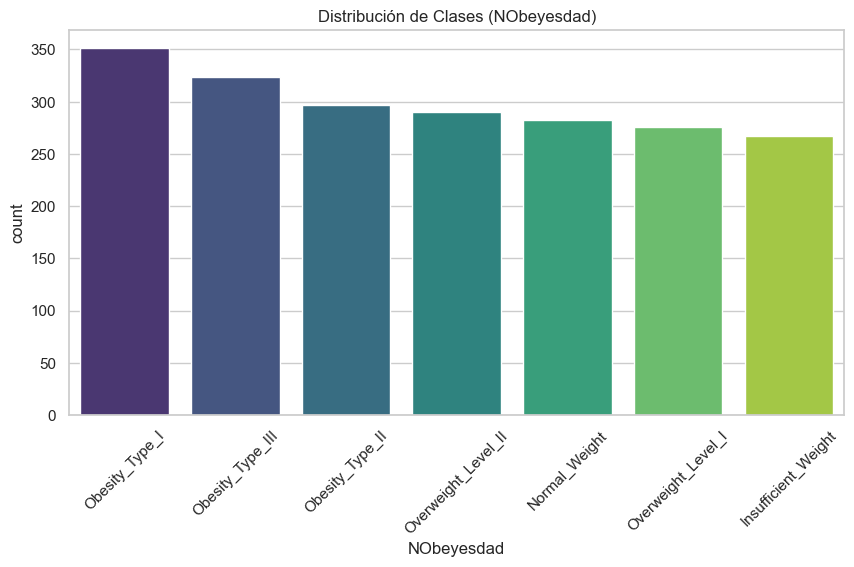

Frecuencia de clases:
 NObeyesdad
Obesity_Type_I         16.818400
Obesity_Type_III       15.524677
Obesity_Type_II        14.230954
Overweight_Level_II    13.895544
Normal_Weight          13.512218
Overweight_Level_I     13.224724
Insufficient_Weight    12.793483
Name: proportion, dtype: float64


In [11]:
plt.figure(figsize=(10, 5))
sns.countplot(x='NObeyesdad', data=df, palette='viridis', order=df['NObeyesdad'].value_counts().index)
plt.title('Distribución de Clases (NObeyesdad)')
plt.xticks(rotation=45)
plt.show()

print("Frecuencia de clases:\n", df['NObeyesdad'].value_counts(normalize=True) * 100)

El análisis de frecuencia de la variable objetivo **NObeyesdad** muestra una distribución equilibrada entre las 7 categorías. Esto garantiza que el modelo de clasificación multiclase no presente sesgos hacia una categoría específica y permite una evaluación de métricas más robusta.

C:\Users\gemit\AppData\Local\Temp\ipykernel_9572\587712667.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='NObeyesdad', y='Weight', palette='magma')


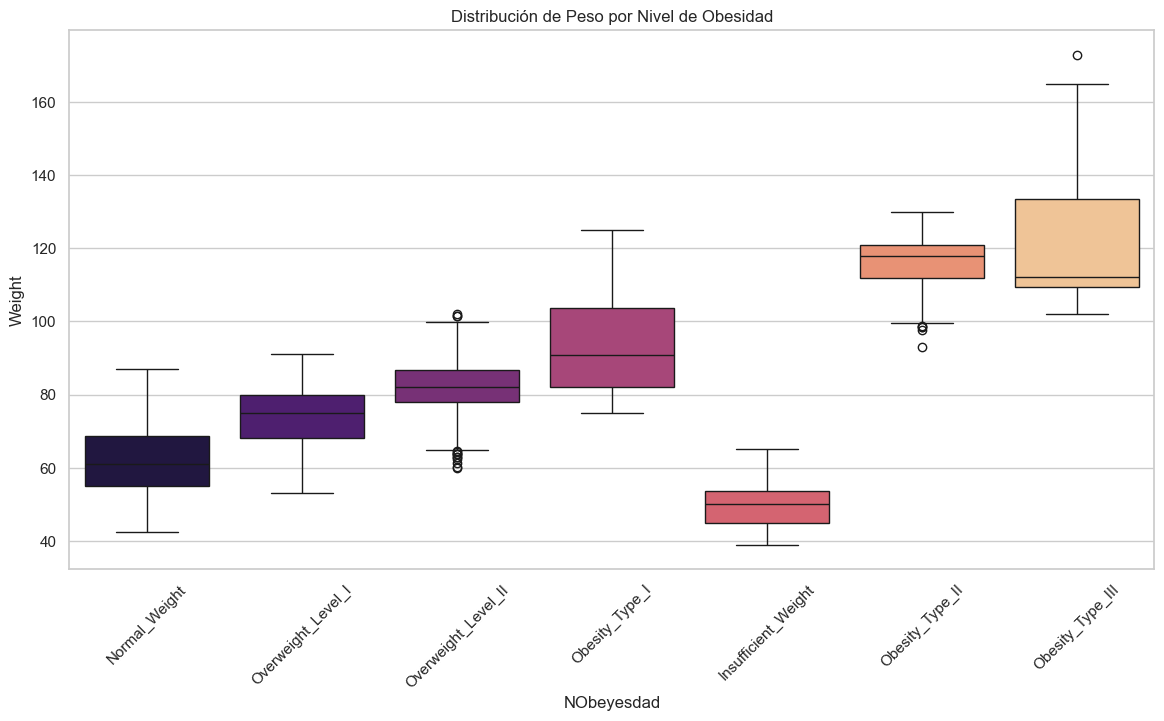

In [12]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='NObeyesdad', y='Weight', palette='magma')
plt.title('Distribución de Peso por Nivel de Obesidad')
plt.xticks(rotation=45)
plt.show()

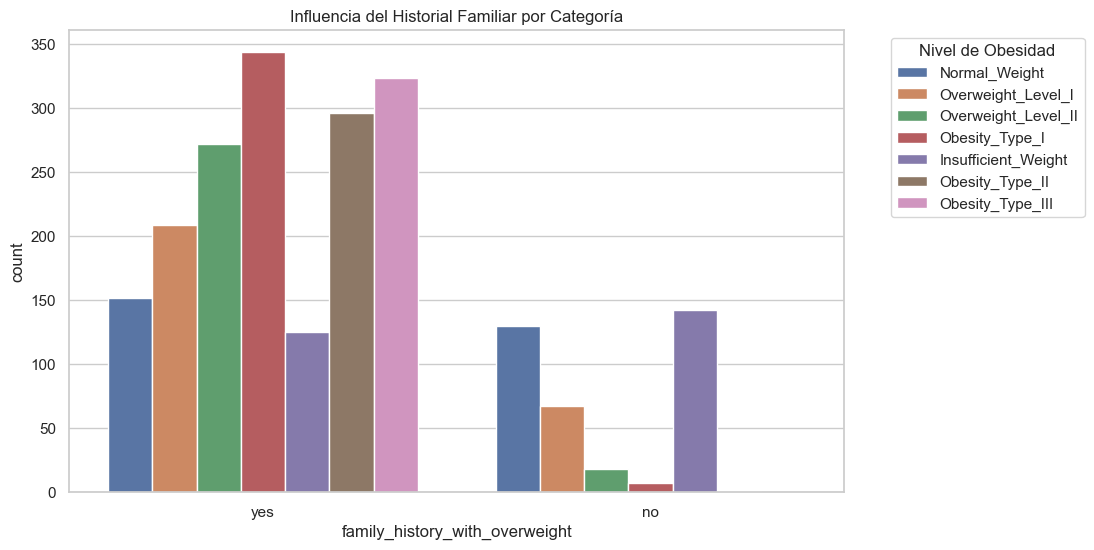

In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='family_history_with_overweight', hue='NObeyesdad')
plt.title('Influencia del Historial Familiar por Categoría')
plt.legend(title='Nivel de Obesidad', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

La variable **family_history_with_overweight** es la más influyentes para distinguir entre los grados más altos de obesidad, porque los grados de obesidad altos porque los familiares tienen todos sobrepreso.

C:\Users\gemit\AppData\Local\Temp\ipykernel_9572\1043429327.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='NObeyesdad', y='CH2O', palette='coolwarm')


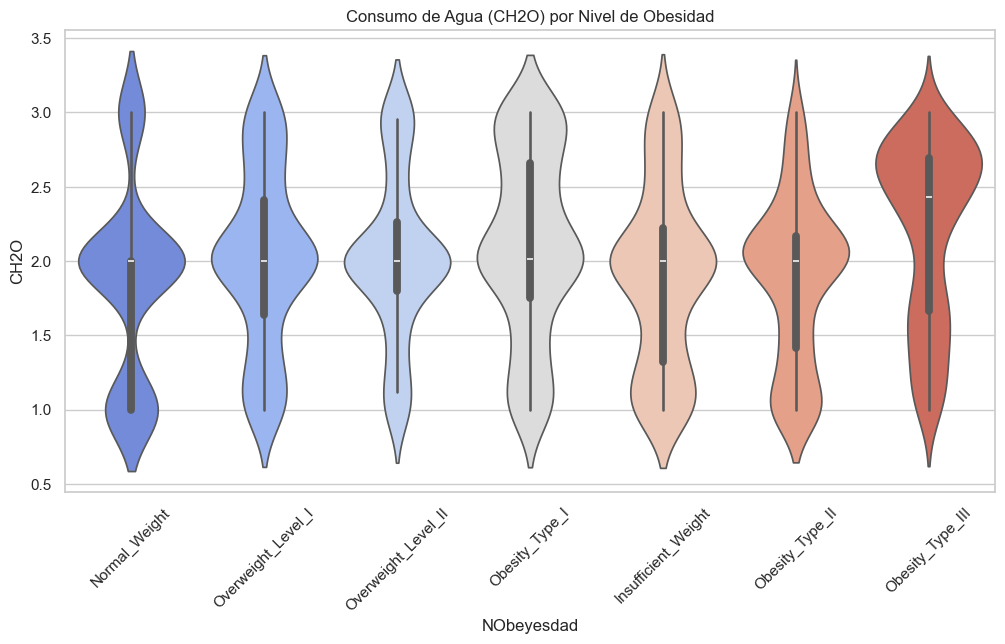

In [14]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='NObeyesdad', y='CH2O', palette='coolwarm')
plt.title('Consumo de Agua (CH2O) por Nivel de Obesidad')
plt.xticks(rotation=45)
plt.show()

El análisis mediante gráficos de violín revela que el consumo de agua **(CH2O)** tiende a ser superior en las categorías de obesidad severa. Mientras que en el peso insuficiente el consumo modal se sitúa cerca de los 2 litros, en la Obesidad Tipo III se observa una mayor densidad de casos alcanzando los 2.5 - 3 litros.

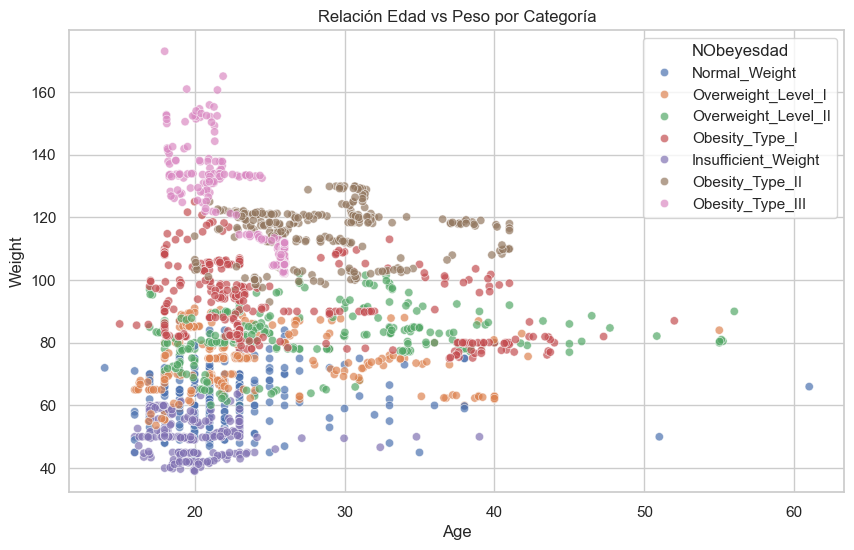

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Weight', hue='NObeyesdad', alpha=0.7)
plt.title('Relación Edad vs Peso por Categoría')
plt.show()

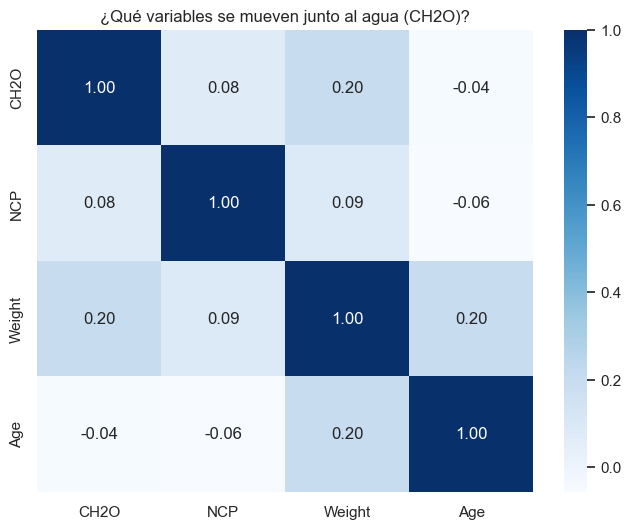

In [16]:
# Seleccionamos las variables de interés
interes = df[['CH2O', 'NCP', 'Weight', 'Age',]]
corr_matrix = interes.corr()

# Dibujamos el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f")
plt.title('¿Qué variables se mueven junto al agua (CH2O)?')
plt.show()

**CH2O** vs **Weight** (Peso): Aquí vemos un 0.20. Es una relación positiva moderada: las personas con más peso suelen reportar un mayor consumo de agua.

In [17]:
# 1. Variables Binarias (Mapeo manual 0/1)
binary_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    # Mapeamos: 'yes' o 'Male' suele ser 1, el resto 0
    if col == 'Gender':
        df[col] = df[col].map({'Male': 1, 'Female': 0})
    else:
        df[col] = df[col].map({'yes': 1, 'no': 0})

# 2. Variables Ordinales (Intensidad 0-3)
# Según tu issue: no:0, Sometimes:1, Frequently:2, Always:3
map_intensidad = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
df['CAEC'] = df['CAEC'].map(map_intensidad)
df['CALC'] = df['CALC'].map(map_intensidad)

# 3. Variables Nominales (One-Hot Encoding)
# Esto creará columnas como MTRANS_Public_Transportation, MTRANS_Walking, etc.
df = pd.get_dummies(df, columns=['MTRANS'], prefix='MTRANS')

# 4. Codificación del Target (NObeyesdad)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['NObeyesdad'] = le.fit_transform(df['NObeyesdad'])

df.head(10)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,...,SCC,FAF,TUE,CALC,NObeyesdad,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0,21.0,1.62,64.0,1,0,2.0,3.0,1,0,...,0,0.0,1.0,0,1,False,False,False,True,False
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1,1,...,1,3.0,0.0,1,1,False,False,False,True,False
2,1,23.0,1.80,77.0,1,0,2.0,3.0,1,0,...,0,2.0,1.0,2,1,False,False,False,True,False
3,1,27.0,1.80,87.0,0,0,3.0,3.0,1,0,...,0,2.0,0.0,2,5,False,False,False,False,True
4,1,22.0,1.78,89.8,0,0,2.0,1.0,1,0,...,0,0.0,0.0,1,6,False,False,False,True,False
5,1,29.0,1.62,53.0,0,1,2.0,3.0,1,0,...,0,0.0,0.0,1,1,True,False,False,False,False
6,0,23.0,1.50,55.0,1,1,3.0,3.0,1,0,...,0,1.0,0.0,1,1,False,False,True,False,False
7,1,22.0,1.64,53.0,0,0,2.0,3.0,1,0,...,0,3.0,0.0,1,1,False,False,False,True,False
8,1,24.0,1.78,64.0,1,1,3.0,3.0,1,0,...,0,1.0,1.0,2,1,False,False,False,True,False
9,1,22.0,1.72,68.0,1,1,2.0,3.0,1,0,...,0,1.0,1.0,0,1,False,False,False,True,False


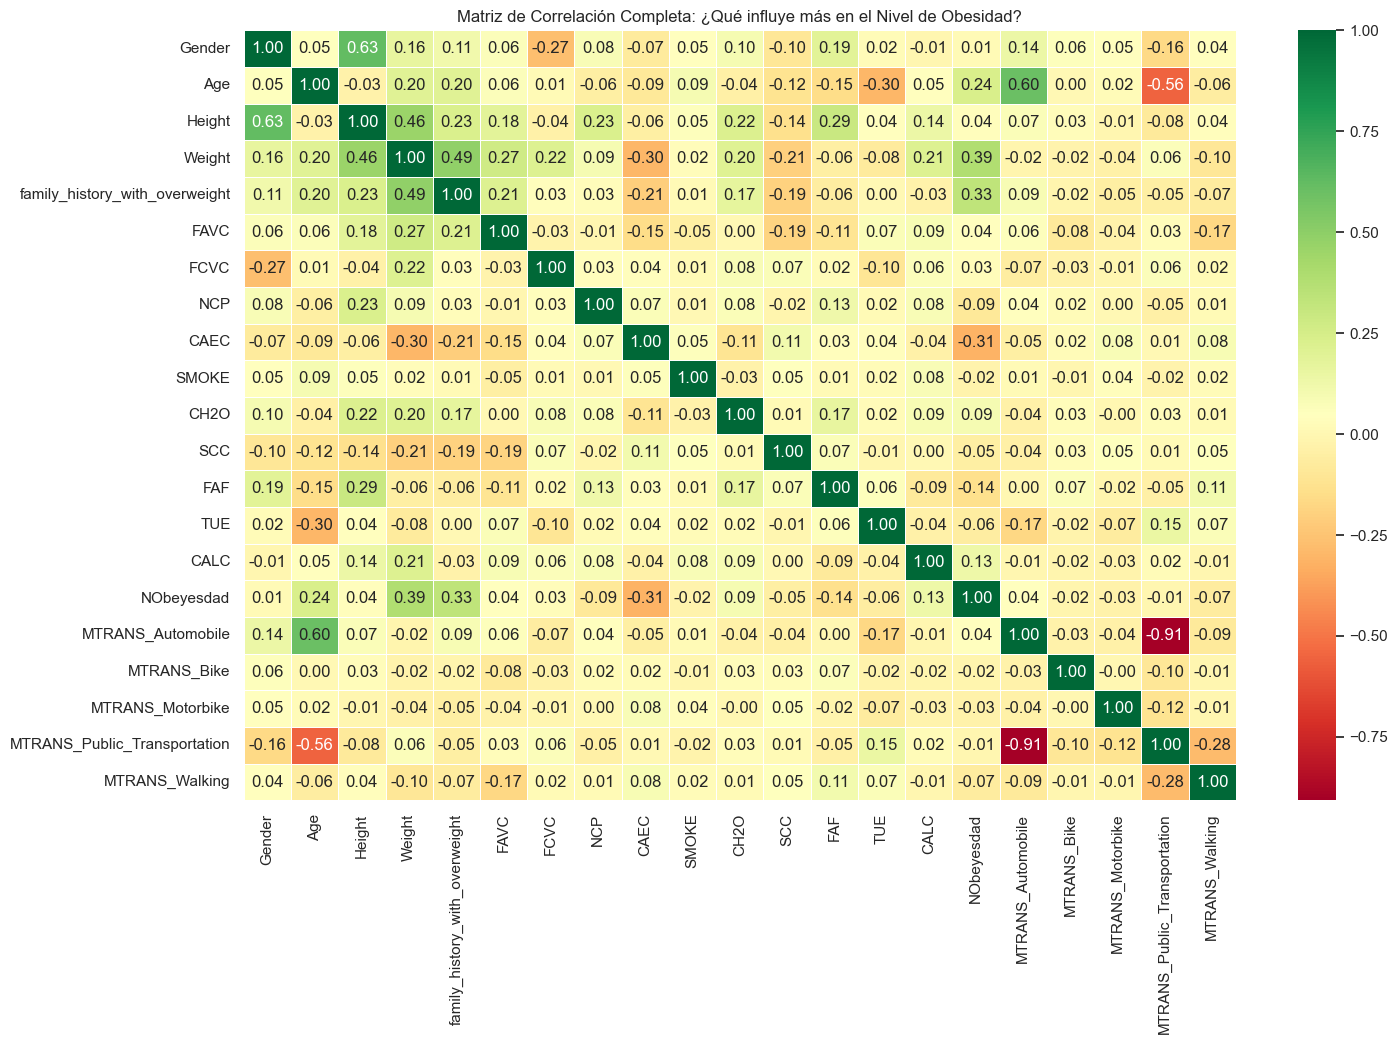

In [18]:
# Calculamos la correlación de TODO el dataframe ahora que es numérico
plt.figure(figsize=(16, 10))
full_corr = df.corr()

# Dibujamos el mapa de calor
sns.heatmap(full_corr, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación Completa: ¿Qué influye más en el Nivel de Obesidad?')
plt.show()

In [19]:
# Ver la correspondencia entre los números y las etiquetas originales
dict(zip(le.classes_, le.transform(le.classes_)))

{'Insufficient_Weight': np.int64(0),
 'Normal_Weight': np.int64(1),
 'Obesity_Type_I': np.int64(2),
 'Obesity_Type_II': np.int64(3),
 'Obesity_Type_III': np.int64(4),
 'Overweight_Level_I': np.int64(5),
 'Overweight_Level_II': np.int64(6)}

In [20]:
df.info()

<class 'pandas.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2087 non-null   int64  
 1   Age                             2087 non-null   float64
 2   Height                          2087 non-null   float64
 3   Weight                          2087 non-null   float64
 4   family_history_with_overweight  2087 non-null   int64  
 5   FAVC                            2087 non-null   int64  
 6   FCVC                            2087 non-null   float64
 7   NCP                             2087 non-null   float64
 8   CAEC                            2087 non-null   int64  
 9   SMOKE                           2087 non-null   int64  
 10  CH2O                            2087 non-null   float64
 11  SCC                             2087 non-null   int64  
 12  FAF                             2087 non-null   fl

Tras el análisis exhaustivo del dataset sobre niveles de obesidad, se extraen las siguientes conclusiones clave para el desarrollo del modelo predictivo:

### Factores Determinantes del Target (NObeyesdad):

* El Peso (Weight) es, como era de esperar, el predictor con mayor correlación positiva (0.39). Sin embargo, al no ser una correlación perfecta, el modelo deberá aprender a combinarlo con otras variables para ser preciso.

* Hábitos Alimenticios: El consumo frecuente de alimentos hipercalóricos (FAVC) muestra una influencia directa y positiva en el aumento del nivel de obesidad.

* Factores Protectores: La actividad física (FAF) presenta una correlación negativa (-0.14), confirmando que niveles más altos de ejercicio se asocian con niveles de obesidad más bajos.

### Calidad y Naturaleza de los Datos:

* El dataset es de alta calidad, sin valores nulos, aunque se identifica la presencia de datos sintéticos (decimales en edad y frecuencia de comidas). Esto es beneficioso para el entrenamiento, ya que proporciona una distribución más equilibrada entre las 7 clases de obesidad.

* Existen solapamientos naturales en variables como el peso entre categorías contiguas (ej. Obesidad II y III), lo que justifica el uso de modelos robustos como XGBoost o Random Forest.

In [21]:
df.to_csv('../data/processed/obesity_cleaned_g.csv', index=False)